# Lecture 5 companion 3 · RMSProp, Adam, schedules, and constraints

We continue with the **same four-example ravine** from the momentum notebook. We will not begin with optimizer names. For every method, we follow one sequence: **problem → intuition → state → update rule → computed outcome → PyTorch check**.

- RMSProp remembers squared gradients to rescale coordinates.
- Adam combines first-moment direction memory with second-moment scaling.
- Learning-rate decay reduces late stochastic wandering.
- Reparameterization or projection keeps constrained parameters feasible.

> Keep asking: what information does the new state remember, and how does that memory repair the failure we just observed?

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

SEED = 12
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
INK, BLUE, TEAL, GREEN, ORANGE, RED, PURPLE = ('#23373B','#2B6CB0','#2C7A7B','#14A66A','#EB811B','#D64550','#7B61A8')
plt.rcParams.update({'figure.figsize': (7.2, 3.4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .18})

X = np.array([[-1.,-10.],[-1.,10.],[1.,-10.],[1.,10.]])
theta_star = np.array([1., -.5])
y = X @ theta_star
theta0 = np.array([-1.4, .35])

def ravine_loss(theta): return 0.5*np.mean((X@theta-y)**2)
def ravine_grad(theta): return X.T@(X@theta-y)/len(X)

theta1_grid, theta2_grid = np.linspace(-1.65,1.45,260), np.linspace(-1.52,.52,260)
THETA1, THETA2 = np.meshgrid(theta1_grid, theta2_grid)
LGRID = .5*(THETA1-theta_star[0])**2 + 50*(THETA2-theta_star[1])**2
LEVELS = [.05,.15,.4,.9,1.8,3.5,7,14,25,40]
assert np.allclose(X.T@X/len(X), np.diag([1.,100.]))
assert np.allclose(ravine_grad(theta0), [-2.4, 85.])
assert np.isclose(ravine_loss(theta0), 39.005)

## 1. RMSProp: give each coordinate its own ruler

### Problem: one global learning rate must serve two very different scales

For Example B,

$$\mathcal L(\boldsymbol\theta)=\tfrac12(\theta_1-1)^2+50(\theta_2+0.5)^2,$$

so $\boldsymbol g=(\theta_1-1,100(\theta_2+0.5))$. At our actual start,

$$\boldsymbol\theta_0=(-1.4,0.35),\qquad \boldsymbol\theta^*=(1,-0.5),\qquad \boldsymbol g_0=(-2.4,85),$$

and $|g_{0,2}|/|g_{0,1}|=35.4$. A learning rate large enough to make visible progress in the shallow $\theta_1$ direction makes the steep $\theta_2$ direction bounce. A rate small enough for $\theta_2$ makes progress in $\theta_1$ slow.

### Intuition: estimate a recent gradient scale for each coordinate

Square each gradient component to forget its sign, average those squares over time, and take a square root. The result acts like a separate **ruler** for each coordinate. A coordinate whose gradients have been large gets a large ruler, so dividing by that ruler shrinks its update more.

### Rule

$$\boldsymbol s_{t+1}=\rho\boldsymbol s_t+(1-\rho)\boldsymbol g_t^{\odot 2},$$

$$\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\frac{\boldsymbol g_t}{\sqrt{\boldsymbol s_{t+1}}+\varepsilon_{\mathrm{opt}}},\qquad \boldsymbol s_0=\boldsymbol 0.$$

Everything is elementwise. In this full-batch demonstration $\boldsymbol g_t$ is the exact gradient. The small $\varepsilon_{\mathrm{opt}}$ only prevents division by zero; $\eta$ still controls the overall step size.

raw gradient g_0                    = [-2.4 85. ]
first squared-gradient memory s_1   = [5.760e-01 7.225e+02]
per-coordinate rulers sqrt(s_1)    = [ 0.7589 26.8794]
rescaled direction g_0/sqrt(s_1)   = [-3.1623  3.1623]
theta_1 = theta_0 - .08 * direction= [-1.147  0.097]


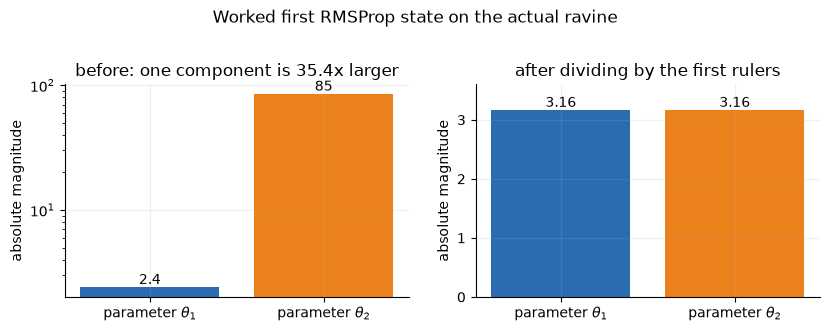

Equal magnitudes here are a first-step zero-start effect:
s_1 = (1-rho) g_0^2, so g_0/sqrt(s_1) = sign(g_0)/sqrt(1-rho).
After this step, each ruler contains a different history; later rescaled components need not match.


In [2]:
rho, eta_rms, eps = .9, .08, 1e-8
g0 = ravine_grad(theta0)
s1 = (1 - rho) * g0**2
ruler1 = np.sqrt(s1)
scaled_g0 = g0 / (ruler1 + eps)
theta1_rms = theta0 - eta_rms * scaled_g0

print('raw gradient g_0                    =', g0)
print('first squared-gradient memory s_1   =', np.round(s1, 4))
print('per-coordinate rulers sqrt(s_1)    =', np.round(ruler1, 4))
print('rescaled direction g_0/sqrt(s_1)   =', np.round(scaled_g0, 4))
print('theta_1 = theta_0 - .08 * direction=', np.round(theta1_rms, 4))

labels = ['parameter $\\theta_1$', 'parameter $\\theta_2$']
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))
axes[0].bar(labels, np.abs(g0), color=[BLUE, ORANGE])
axes[0].set(yscale='log', ylabel='absolute magnitude', title='before: one component is 35.4x larger')
axes[1].bar(labels, np.abs(scaled_g0), color=[BLUE, ORANGE])
axes[1].set(ylim=(0, 3.6), ylabel='absolute magnitude', title='after dividing by the first rulers')
for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.3g}',
                ha='center', va='bottom')
plt.suptitle('Worked first RMSProp state on the actual ravine', y=1.02)
plt.tight_layout(); plt.show()

print('Equal magnitudes here are a first-step zero-start effect:')
print('s_1 = (1-rho) g_0^2, so g_0/sqrt(s_1) = sign(g_0)/sqrt(1-rho).')
print('After this step, each ruler contains a different history; later rescaled components need not match.')
assert np.allclose(g0, [-2.4, 85.])
assert np.allclose(s1, [.576, 722.5])
assert np.allclose(np.abs(scaled_g0), [np.sqrt(10), np.sqrt(10)], atol=1e-6)
assert np.allclose(theta1_rms, [-1.14701779, .09701779], atol=1e-8)

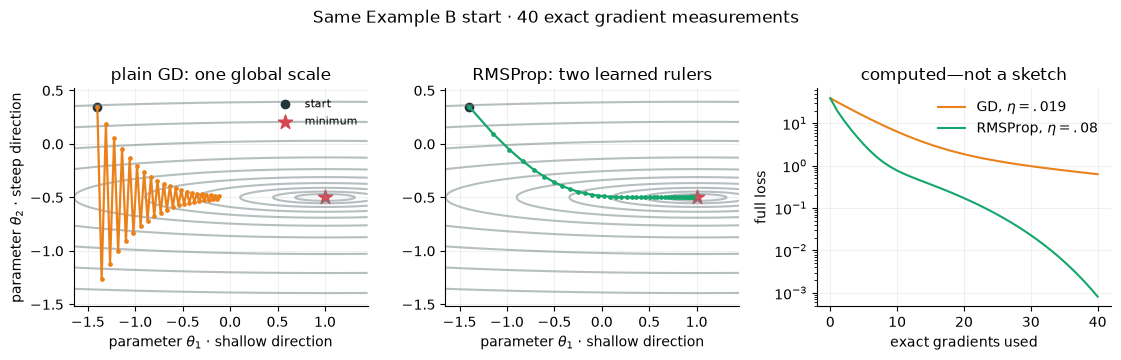

starting loss                 = 39.005000
GD loss after 40 gradients     = 0.628637 | theta2 crossings=40
RMSProp loss after 40 gradients= 0.000815 | theta2 crossings=4
The learning rates are tuned separately because the update formulas have different scales.


In [3]:
def rmsprop_trace(eta=.08, rho=.9, steps=55, eps=1e-8):
    theta, scale = theta0.copy(), np.zeros(2)
    path, scales = [theta.copy()], [scale.copy()]
    for _ in range(steps):
        g = ravine_grad(theta)
        scale = rho * scale + (1 - rho) * g**2
        theta -= eta * g / (np.sqrt(scale) + eps)
        path.append(theta.copy()); scales.append(scale.copy())
    return np.asarray(path), np.asarray(scales)

def rmsprop_path(eta=.08, rho=.9, steps=55, eps=1e-8):
    return rmsprop_trace(eta, rho, steps, eps)[0]

def gd_path(eta=.019, steps=55):
    theta, path = theta0.copy(), [theta0.copy()]
    for _ in range(steps):
        theta -= eta * ravine_grad(theta); path.append(theta.copy())
    return np.asarray(path)

# A real outcome: both methods receive 40 exact full-batch gradients.
plain = gd_path(steps=40)
rms, rms_scales = rmsprop_trace(steps=40)
plain_losses = np.array([ravine_loss(theta) for theta in plain])
rms_losses = np.array([ravine_loss(theta) for theta in rms])

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.45))
for ax, path_now, title, color in [(axes[0], plain, 'plain GD: one global scale', ORANGE),
                                    (axes[1], rms, 'RMSProp: two learned rulers', GREEN)]:
    ax.contour(THETA1, THETA2, LGRID, levels=LEVELS, colors='#6E7F82', alpha=.5)
    ax.plot(path_now[:, 0], path_now[:, 1], 'o-', ms=2.4, lw=1.6, color=color)
    ax.scatter(*theta0, color=INK, label='start')
    ax.scatter(*theta_star, marker='*', s=115, color=RED, label='minimum')
    ax.set(title=title, xlabel='parameter $\\theta_1$ · shallow direction',
           xlim=(-1.65, 1.45), ylim=(-1.52, .52))
axes[0].set_ylabel('parameter $\\theta_2$ · steep direction'); axes[0].legend(frameon=False, fontsize=8)
axes[2].semilogy(plain_losses, color=ORANGE, label='GD, $\\eta=.019$')
axes[2].semilogy(rms_losses, color=GREEN, label='RMSProp, $\\eta=.08$')
axes[2].set(xlabel='exact gradients used', ylabel='full loss', title='computed—not a sketch')
axes[2].legend(frameon=False)
plt.suptitle('Same Example B start · 40 exact gradient measurements', y=1.03)
plt.tight_layout(); plt.show()

def sign_changes_about(values, center):
    centered = np.asarray(values) - center
    return int(np.sum(np.sign(centered[:-1]) * np.sign(centered[1:]) < 0))

plain_crossings = sign_changes_about(plain[:, 1], theta_star[1])
rms_crossings = sign_changes_about(rms[:, 1], theta_star[1])
print(f'starting loss                 = {ravine_loss(theta0):.6f}')
print(f'GD loss after 40 gradients     = {plain_losses[-1]:.6f} | theta2 crossings={plain_crossings}')
print(f'RMSProp loss after 40 gradients= {rms_losses[-1]:.6f} | theta2 crossings={rms_crossings}')
print('The learning rates are tuned separately because the update formulas have different scales.')
assert np.isclose(plain_losses[-1], 0.6286371741979371)
assert np.isclose(rms_losses[-1], 0.0008152220927773294)
assert rms_crossings < plain_crossings

### Only now check the framework state

We have seen the problem, derived the rule, worked out its first state, and run the real path. Now verify that PyTorch stores the same per-coordinate rulers. With momentum, centering, and weight decay disabled, `torch.optim.RMSprop` follows our recurrence. We use float64 so any disagreement is easy to see.

In [4]:
steps = 15
numpy_rms, numpy_square = rmsprop_trace(eta_rms, rho, steps, eps)
Xt = torch.tensor(X, dtype=torch.float64)
yt = torch.tensor(y, dtype=torch.float64)
theta_param = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
opt = torch.optim.RMSprop([theta_param], lr=eta_rms, alpha=rho, eps=eps,
                          momentum=0, centered=False, weight_decay=0)
torch_rms = [theta_param.detach().numpy().copy()]
torch_square = [np.zeros_like(theta0)]
for _ in range(steps):
    opt.zero_grad(set_to_none=True)
    objective = .5 * ((Xt @ theta_param - yt)**2).mean()
    objective.backward(); opt.step()
    torch_rms.append(theta_param.detach().numpy().copy())
    torch_square.append(opt.state[theta_param]['square_avg'].detach().numpy().copy())
torch_rms, torch_square = np.asarray(torch_rms), np.asarray(torch_square)

print('first three PyTorch square_avg states:\n', torch_square[1:4])
print(f'maximum RMSProp parameter-path difference: {np.max(np.abs(torch_rms-numpy_rms)):.3e}')
print(f'maximum square_avg-history difference:      {np.max(np.abs(torch_square-numpy_square)):.3e}')
print(f'final RMSProp loss:                         {ravine_loss(torch_rms[-1]):.3e}')
assert np.allclose(torch_rms, numpy_rms, atol=1e-12)
assert np.allclose(torch_square, numpy_square, atol=1e-12)
assert np.allclose(torch_square[1], [.576, 722.5])

first three PyTorch square_avg states:
 [[5.76000000e-01 7.22500000e+02]
 [9.79368539e-01 1.00668024e+03]
 [1.27088479e+00 1.10536095e+03]]
maximum RMSProp parameter-path difference: 1.943e-16
maximum square_avg-history difference:      1.137e-13
final RMSProp loss:                         3.626e-01


## 2. Adam: combine the two repairs

### Two earlier methods solved two different problems

- **Momentum remembers signed gradients.** Opposing steep-direction gradients can cancel, while a persistent shallow direction accumulates. It addresses alternating direction, but one global learning rate still serves every coordinate.
- **RMSProp remembers squared gradients.** It learns one ruler per coordinate and addresses scale imbalance, but squaring discards the sign and therefore does not carry momentum's directional memory.

### Adam's intuition

Keep both memories: a signed EWMA $\boldsymbol m_t$ for direction and a squared-gradient EWMA $\boldsymbol v_t$ for coordinate scale. Move along the remembered direction after dividing each component by its learned ruler.

### Bias correction is the same missing-mass correction used for EWMA

Both memories start at zero. After $t$ readings, their EWMA weights sum to $1-\beta^t$, not yet to one. Dividing by that known mass removes the temporary pull toward zero; it does **not** use future gradients.

$$\boldsymbol m_t=\beta_1\boldsymbol m_{t-1}+(1-\beta_1)\boldsymbol g_t,\qquad \boldsymbol v_t=\beta_2\boldsymbol v_{t-1}+(1-\beta_2)\boldsymbol g_t^{\odot 2},$$

$$\widehat{\boldsymbol m}_t=\frac{\boldsymbol m_t}{1-\beta_1^t},\qquad \widehat{\boldsymbol v}_t=\frac{\boldsymbol v_t}{1-\beta_2^t},$$

$$\boldsymbol\theta_t=\boldsymbol\theta_{t-1}-\eta\frac{\widehat{\boldsymbol m}_t}{\sqrt{\widehat{\boldsymbol v}_t}+\varepsilon_{\mathrm{opt}}}.$$

We initialize $\boldsymbol m_0=\boldsymbol v_0=\boldsymbol 0$. The code below first exposes the state, then runs the actual ravine path.

g_0                         = [-2.4 85. ]
m_1 (signed memory)         = [-0.24  8.5 ]
v_1 (squared memory)        = [5.760e-03 7.225e+00]
bias-corrected m_hat_1      = [-2.4 85. ]
bias-corrected v_hat_1      = [5.760e+00 7.225e+03]
m_hat_1 / sqrt(v_hat_1)    = [-1.  1.]
theta_1                    = [-1.3   0.25]


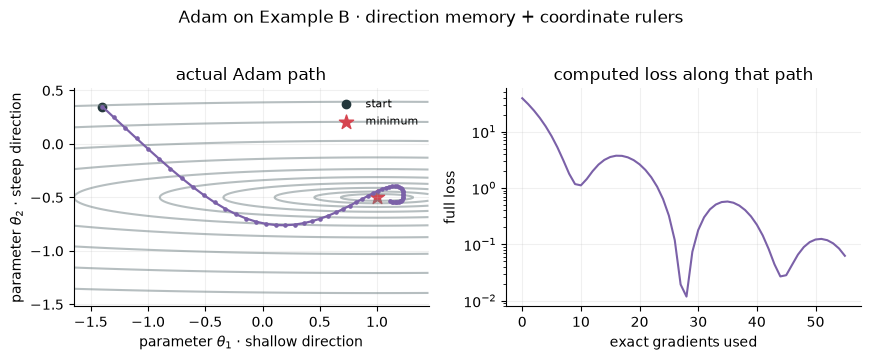

Adam loss: 39.005000 -> 0.062601 after 55 gradients
Adam steep-coordinate crossings: 3


In [5]:
def adam_trace(eta=.10, beta1=.9, beta2=.999, steps=55, eps=1e-8):
    theta, m, v = theta0.copy(), np.zeros(2), np.zeros(2)
    path, first_hist, second_hist = [theta.copy()], [m.copy()], [v.copy()]
    for t in range(1, steps + 1):
        g = ravine_grad(theta)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta -= eta * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy()); first_hist.append(m.copy()); second_hist.append(v.copy())
    return np.asarray(path), np.asarray(first_hist), np.asarray(second_hist)

def adam_path(eta=.10, beta1=.9, beta2=.999, steps=55, eps=1e-8):
    return adam_trace(eta, beta1, beta2, steps, eps)[0]

# Work out the first state before looking at a whole trajectory.
beta1, beta2, eta_adam = .9, .999, .10
m1 = (1 - beta1) * g0
v1 = (1 - beta2) * g0**2
m1_hat = m1 / (1 - beta1)
v1_hat = v1 / (1 - beta2)
adam_direction1 = m1_hat / (np.sqrt(v1_hat) + eps)
theta1_adam = theta0 - eta_adam * adam_direction1
print('g_0                         =', g0)
print('m_1 (signed memory)         =', np.round(m1, 6))
print('v_1 (squared memory)        =', np.round(v1, 6))
print('bias-corrected m_hat_1      =', np.round(m1_hat, 6))
print('bias-corrected v_hat_1      =', np.round(v1_hat, 6))
print('m_hat_1 / sqrt(v_hat_1)    =', np.round(adam_direction1, 6))
print('theta_1                    =', np.round(theta1_adam, 6))

adam, adam_m, adam_v = adam_trace(steps=55)
adam_losses = np.array([ravine_loss(theta) for theta in adam])
fig, axes = plt.subplots(1, 2, figsize=(8.9, 3.45))
axes[0].contour(THETA1, THETA2, LGRID, levels=LEVELS, colors='#6E7F82', alpha=.5)
axes[0].plot(adam[:, 0], adam[:, 1], 'o-', ms=2.3, lw=1.6, color=PURPLE)
axes[0].scatter(*theta0, color=INK, label='start'); axes[0].scatter(*theta_star, marker='*', s=115, color=RED, label='minimum')
axes[0].set(xlabel='parameter $\\theta_1$ · shallow direction',
            ylabel='parameter $\\theta_2$ · steep direction',
            title='actual Adam path', xlim=(-1.65, 1.45), ylim=(-1.52, .52))
axes[0].legend(frameon=False, fontsize=8)
axes[1].semilogy(adam_losses, color=PURPLE)
axes[1].set(xlabel='exact gradients used', ylabel='full loss', title='computed loss along that path')
plt.suptitle('Adam on Example B · direction memory + coordinate rulers', y=1.03)
plt.tight_layout(); plt.show()

adam_crossings = sign_changes_about(adam[:, 1], theta_star[1])
print(f'Adam loss: {adam_losses[0]:.6f} -> {adam_losses[-1]:.6f} after 55 gradients')
print(f'Adam steep-coordinate crossings: {adam_crossings}')
assert np.allclose(adam[1], theta1_adam, atol=1e-8)
assert np.isclose(adam_losses[-1], 0.06260063530642351)

### Now check Adam's two memories against PyTorch

The mechanism and computed path came first. The framework check below verifies the complete parameter history plus both stored states: `exp_avg` is the signed direction memory $\mathbf m_t$, and `exp_avg_sq` is the squared-gradient scale memory $\mathbf v_t$.

In [6]:
steps = 15
numpy_adam, numpy_exp_avg, numpy_exp_avg_sq = adam_trace(steps=steps)
theta_param = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
opt = torch.optim.Adam([theta_param], lr=.10, betas=(.9, .999), eps=1e-8, weight_decay=0)
torch_adam = [theta_param.detach().numpy().copy()]
torch_exp_avg, torch_exp_avg_sq = [np.zeros_like(theta0)], [np.zeros_like(theta0)]
for _ in range(steps):
    opt.zero_grad(set_to_none=True)
    objective = .5 * ((Xt @ theta_param - yt)**2).mean()
    objective.backward(); opt.step()
    state = opt.state[theta_param]
    torch_adam.append(theta_param.detach().numpy().copy())
    torch_exp_avg.append(state['exp_avg'].detach().numpy().copy())
    torch_exp_avg_sq.append(state['exp_avg_sq'].detach().numpy().copy())
torch_adam = np.asarray(torch_adam)
torch_exp_avg, torch_exp_avg_sq = np.asarray(torch_exp_avg), np.asarray(torch_exp_avg_sq)

print('first PyTorch exp_avg state:   ', torch_exp_avg[1])
print('first PyTorch exp_avg_sq state:', torch_exp_avg_sq[1])
print(f'maximum Adam parameter-path difference: {np.max(np.abs(torch_adam-numpy_adam)):.3e}')
print(f'maximum exp_avg-history difference:      {np.max(np.abs(torch_exp_avg-numpy_exp_avg)):.3e}')
print(f'maximum exp_avg_sq-history difference:   {np.max(np.abs(torch_exp_avg_sq-numpy_exp_avg_sq)):.3e}')
assert np.allclose(torch_adam, numpy_adam, atol=1e-12)
assert np.allclose(torch_exp_avg, numpy_exp_avg, atol=1e-12)
assert np.allclose(torch_exp_avg_sq, numpy_exp_avg_sq, atol=1e-12)

first PyTorch exp_avg state:    [-0.24  8.5 ]
first PyTorch exp_avg_sq state: [5.760e-03 7.225e+00]
maximum Adam parameter-path difference: 1.110e-16
maximum exp_avg-history difference:      5.329e-15
maximum exp_avg_sq-history difference:   6.939e-18


## 3. One ravine, four mechanisms

Every run below starts at the same actual parameters $\boldsymbol\theta_0=(-1.4,.35)$ and receives 55 exact full-batch gradients of the same four-example empirical loss. We put all four loss curves on **one shared axis** so the evidence is readable before interpreting the optimizer names.

The learning rates are chosen separately because the update formulas have different units and scales. This is a **controlled example, not a universal optimizer ranking**:

- GD uses the raw gradient;
- momentum filters its direction;
- RMSProp rescales each coordinate;
- Adam combines signed direction memory with per-coordinate rulers, correcting both zero-start memories.

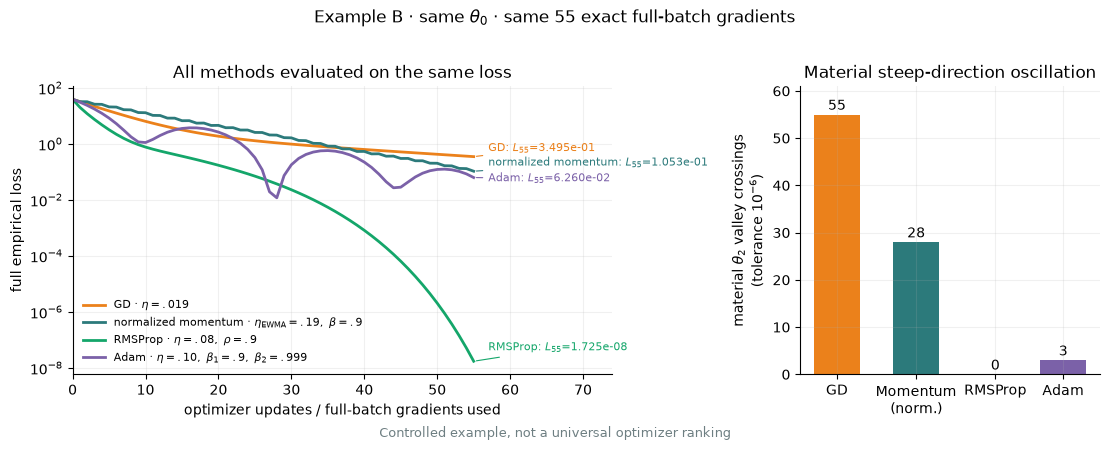

Controlled Example B | same theta0 | 55 exact full-batch gradients
rank  method                    L_55          theta2 valley crossings
   1  RMSProp                 1.724812e-08                        0
   2  Adam                    6.260064e-02                        3
   3  normalized momentum     1.052624e-01                       28
   4  GD                      3.494615e-01                       55
Here: adaptive scaling finishes lower. RMSProp has the lowest L_55 and
zero material theta2 crossings; Adam has 3. This is not a universal ranking.


In [7]:
def momentum_path(eta=.19, beta=.9, steps=55):
    theta, m, path = theta0.copy(), np.zeros(2), [theta0.copy()]
    for _ in range(steps):
        m = beta * m + (1 - beta) * ravine_grad(theta)
        theta -= eta * m; path.append(theta.copy())
    return np.asarray(path)

def material_crossings(path, tolerance=1e-6):
    steep_error = np.asarray(path)[:, 1] - theta_star[1]
    changed_sign_bit = np.signbit(steep_error[:-1]) != np.signbit(steep_error[1:])
    adjacent_scale = np.maximum(np.abs(steep_error[:-1]), np.abs(steep_error[1:]))
    return int(np.sum(changed_sign_bit & (adjacent_scale > tolerance)))

methods = [
    ('GD', gd_path(.019, 55), ORANGE, r'$\eta=.019$'),
    ('normalized momentum', momentum_path(.19, .9, 55), TEAL, r'$\eta_{\rm EWMA}=.19,\ \beta=.9$'),
    ('RMSProp', rmsprop_path(.08, .9, 55), GREEN, r'$\eta=.08,\ \rho=.9$'),
    ('Adam', adam_path(.10, .9, .999, 55), PURPLE, r'$\eta=.10,\ \beta_1=.9,\ \beta_2=.999$'),
]
metrics = []
for name, path_now, color, rate_label in methods:
    losses = np.array([ravine_loss(theta) for theta in path_now])
    metrics.append({'name': name, 'path': path_now, 'color': color, 'rate': rate_label,
                    'losses': losses, 'L55': losses[-1],
                    'crossings': material_crossings(path_now)})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.15),
                         gridspec_kw={'width_ratios': [1.8, 1]})
for item in metrics:
    axes[0].semilogy(range(56), item['losses'], lw=2.0, color=item['color'],
                    label=f"{item['name']} · {item['rate']}")
axes[0].set(xlabel='optimizer updates / full-batch gradients used',
            ylabel='full empirical loss', xlim=(0, 74),
            title='All methods evaluated on the same loss')
axes[0].legend(frameon=False, fontsize=8, loc='lower left')

# Endpoint labels make the controlled L_55 result explicit.
endpoint_y = {'GD': .52, 'normalized momentum': .16, 'Adam': .044, 'RMSProp': 4.0e-8}
for item in metrics:
    axes[0].annotate(f"{item['name']}: $L_{{55}}$={item['L55']:.3e}",
                     xy=(55, item['L55']), xytext=(57, endpoint_y[item['name']]),
                     color=item['color'], fontsize=8,
                     arrowprops={'arrowstyle': '-', 'color': item['color'], 'lw': .8})

names = ['GD', 'Momentum\n(norm.)', 'RMSProp', 'Adam']
crossings = [item['crossings'] for item in metrics]
colors = [item['color'] for item in metrics]
bar_x = np.array([0., 1.4, 2.8, 4.0])
bars = axes[1].bar(bar_x, crossings, width=.82, color=colors)
axes[1].set_xticks(bar_x, names); axes[1].set_xlim(-.65, 4.65)
axes[1].set(ylabel='material $\\theta_2$ valley crossings\n(tolerance $10^{-6}$)',
            title='Material steep-direction oscillation', ylim=(0, 61))
for bar, count in zip(bars, crossings):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

fig.suptitle('Example B · same $\\theta_0$ · same 55 exact full-batch gradients', y=1.02)
fig.text(.5, -.01, 'Controlled example, not a universal optimizer ranking',
         ha='center', color='#6E7F82', fontsize=9)
plt.tight_layout(); plt.show()

ranking = sorted(metrics, key=lambda item: item['L55'])
print('Controlled Example B | same theta0 | 55 exact full-batch gradients')
print('rank  method                    L_55          theta2 valley crossings')
for rank, item in enumerate(ranking, start=1):
    print(f"{rank:>4}  {item['name']:<23} {item['L55']:.6e}  {item['crossings']:>23}")
print('Here: adaptive scaling finishes lower. RMSProp has the lowest L_55 and')
print('zero material theta2 crossings; Adam has 3. This is not a universal ranking.')

metric_by_name = {item['name']: item for item in metrics}
assert [item['name'] for item in ranking] == ['RMSProp', 'Adam', 'normalized momentum', 'GD']
assert metric_by_name['GD']['crossings'] == 55
assert metric_by_name['normalized momentum']['crossings'] == 28
assert metric_by_name['RMSProp']['crossings'] == 0
assert metric_by_name['Adam']['crossings'] == 3
assert metric_by_name['RMSProp']['L55'] < metric_by_name['Adam']['L55']
assert metric_by_name['Adam']['L55'] < metric_by_name['normalized momentum']['L55']

## 4. Learning-rate decay: chosen rate → actual distance → late path

Return to Example A and compare two SGD runs with the same start and the same 360 sampled indices (seed 12):

$$\text{fixed: }\eta_t=.10,\qquad \text{inverse-time decay: }\eta_t=\frac{.10}{1+.02t}.$$

The visual follows one causal chain. **First**, inspect the rate we choose. **Next**, measure how far the parameters actually move over the final 99 transitions. **Finally**, inspect those final 100 path points near the least-squares optimum. The sampled examples and optimizer are controlled; only the rate policy changes. This is a mechanism demonstration, not a universal schedule ranking.

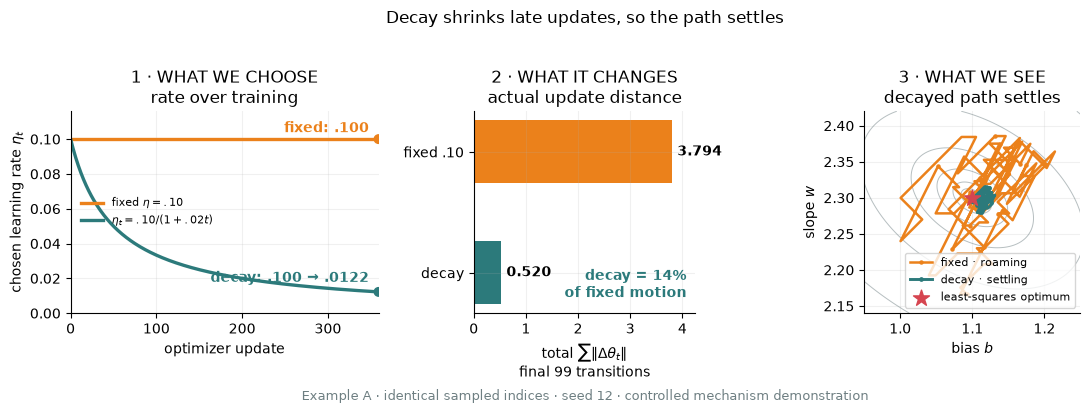

decayed rate: 0.100000 -> 0.0122249389 at update 359
actual distance over final 99 transitions | fixed=3.794479822 | decay=0.520387237
the fixed path travels 7.29164659x as far as the decayed path


In [8]:
x_line = np.array([-1., 0., 1., 2.]); y_line = np.array([-1., 1., 3., 6.])
A_line = np.column_stack([np.ones_like(x_line), x_line]); theta_line0 = np.array([2., -1.])
theta_line_star = np.linalg.lstsq(A_line, y_line, rcond=None)[0]

def line_loss(theta): return .5 * np.mean((A_line @ theta - y_line)**2)
def sample_grad(theta, i):
    residual = A_line[i] @ theta - y_line[i]
    return residual * A_line[i]
def run_stream(indices, schedule):
    theta, path, losses = theta_line0.copy(), [theta_line0.copy()], []
    for t, i in enumerate(indices):
        theta -= schedule(t) * sample_grad(theta, i)
        path.append(theta.copy()); losses.append(line_loss(theta))
    return np.asarray(path), np.asarray(losses)

rng = np.random.default_rng(SEED); indices = rng.integers(0, 4, 360)
ETA0, DECAY = .10, .02
fixed_path, fixed_loss = run_stream(indices, lambda _t: ETA0)
decay_path, decay_loss = run_stream(indices, lambda t: ETA0 / (1 + DECAY * t))
updates = np.arange(len(indices))
fixed_rates = np.full(len(indices), ETA0)
decay_rates = ETA0 / (1 + DECAY * updates)
fixed_steps = np.linalg.norm(np.diff(fixed_path, axis=0), axis=1)
decay_steps = np.linalg.norm(np.diff(decay_path, axis=0), axis=1)
# The final 100 path points contain 99 actual parameter transitions.
fixed_late_distance = fixed_steps[-99:].sum()
decay_late_distance = decay_steps[-99:].sum()
distance_ratio = fixed_late_distance / decay_late_distance
decay_motion_percent = 100 * decay_late_distance / fixed_late_distance

fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.75),
                         gridspec_kw={'width_ratios': [1., .72, 1.18]})
# 1 · the rate policy we choose
axes[0].plot(updates, fixed_rates, color=ORANGE, lw=2.4, label=r'fixed $\eta=.10$')
axes[0].plot(updates, decay_rates, color=TEAL, lw=2.4, label=r'$\eta_t=.10/(1+.02t)$')
axes[0].scatter([updates[-1]]*2, [fixed_rates[-1], decay_rates[-1]],
                color=[ORANGE, TEAL], s=38, zorder=5)
axes[0].text(348, .104, 'fixed: .100', color=ORANGE, ha='right', weight='bold')
axes[0].text(348, .018, 'decay: .100 → .0122', color=TEAL, ha='right', weight='bold')
axes[0].set(xlim=(0, 359), ylim=(0, .116), xlabel='optimizer update',
            ylabel=r'chosen learning rate $\eta_t$', title='1 · WHAT WE CHOOSE\nrate over training')
axes[0].legend(frameon=False, fontsize=8, loc='center left')

# 2 · the distance the parameters actually move
bars = axes[1].barh([0, 1], [fixed_late_distance, decay_late_distance],
                     color=[ORANGE, TEAL], height=.52)
axes[1].invert_yaxis(); axes[1].set_yticks([0, 1], ['fixed .10', 'decay'])
axes[1].bar_label(bars, labels=[f'{fixed_late_distance:.3f}', f'{decay_late_distance:.3f}'],
                  padding=4, fontsize=10, weight='bold')
axes[1].text(.96, .08, f'decay = {decay_motion_percent:.0f}%\nof fixed motion', transform=axes[1].transAxes,
             ha='right', color=TEAL, weight='bold')
axes[1].set(xlim=(0, 4.25), xlabel=r'total $\sum\|\Delta\theta_t\|$' + '\nfinal 99 transitions',
            title='2 · WHAT IT CHANGES\nactual update distance')

# 3 · the resulting final-100 paths
b = np.linspace(.95, 1.25, 220); w = np.linspace(2.14, 2.42, 220)
B, W = np.meshgrid(b, w); optimum = line_loss(theta_line_star)
LG = .5 * np.mean((B[..., None] + W[..., None] * x_line - y_line)**2, axis=-1)
axes[2].contour(B, W, LG, levels=optimum + np.array([.0001,.0003,.001,.003,.01,.03]),
                colors='#6E7F82', linewidths=.7, alpha=.5)
axes[2].plot(fixed_path[-100:, 0], fixed_path[-100:, 1], color=ORANGE, lw=1.8,
             marker='o', ms=2.2, markevery=9, label='fixed · roaming')
axes[2].plot(decay_path[-100:, 0], decay_path[-100:, 1], color=TEAL, lw=2.1,
             marker='o', ms=2.4, markevery=9, label='decay · settling')
axes[2].scatter(*theta_line_star, marker='*', s=145, color=RED, zorder=6,
                label='least-squares optimum')
axes[2].set(xlim=(.95, 1.25), ylim=(2.14, 2.42), xlabel='bias $b$', ylabel='slope $w$',
            title='3 · WHAT WE SEE\ndecayed path settles')
axes[2].set_aspect('equal'); axes[2].legend(frameon=True, fontsize=8, loc='lower right')
fig.suptitle('Decay shrinks late updates, so the path settles', y=1.03)
fig.text(.5, -.01, 'Example A · identical sampled indices · seed 12 · controlled mechanism demonstration',
         ha='center', color='#6E7F82', fontsize=9)
plt.tight_layout(); plt.show()

print(f'decayed rate: {decay_rates[0]:.6f} -> {decay_rates[-1]:.10f} at update 359')
print(f'actual distance over final 99 transitions | fixed={fixed_late_distance:.9f} | decay={decay_late_distance:.9f}')
print(f'the fixed path travels {distance_ratio:.8f}x as far as the decayed path')
assert np.isclose(decay_rates[-1], .012224938875305624)
assert np.isclose(fixed_late_distance, 3.794479821649366)
assert np.isclose(decay_late_distance, .520387236914856)
assert np.isclose(distance_ratio, 7.291646590229894)
assert np.allclose(fixed_path[0], decay_path[0])

### The exact same inverse-time schedule in PyTorch

The computed experiment uses $\eta_t=\eta_0/(1+dt)$ and advances $t$ once per **optimizer update**. `LambdaLR` can implement precisely that clock. Call `optimizer.step()` first, then `scheduler.step()` so the rate selected for update $t+1$ is ready.

In [9]:
eta0, decay, num_updates = .10, .02, 8
dummy = torch.nn.Parameter(torch.tensor(1.0))
optimizer = torch.optim.SGD([dummy], lr=eta0)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda t: 1.0 / (1.0 + decay * t))

rates_used = []
for update in range(num_updates):
    rates_used.append(optimizer.param_groups[0]['lr'])
    optimizer.zero_grad(set_to_none=True)
    (0.5 * dummy.square()).backward()
    optimizer.step()       # parameter update t uses eta_t
    scheduler.step()       # prepare eta_(t+1)

expected_rates = np.array([eta0 / (1 + decay * t) for t in range(num_updates)])
print('rates used per optimizer update:', np.round(rates_used, 6))
assert np.allclose(rates_used, expected_rates)

rates used per optimizer update: [0.1      0.098039 0.096154 0.09434  0.092593 0.090909 0.089286 0.087719]


## 5. The optimizer can propose an invalid parameter

Suppose a Gaussian model has scale $s>0$. For the deliberately simple slice $y=\mu$, its negative log-likelihood is

$$\mathcal L(s)=\log s + \text{constant},\qquad \frac{\partial\mathcal L}{\partial s}=\frac1s.$$

At $s_0=.10$, the gradient is $10$. A plain step with $\eta=.02$ proposes

$$s_1=.10-.02(10)=-.10,$$

which is not a valid Gaussian scale. Autograd computed the derivative correctly; the unconstrained optimizer simply does not know that $s$ must remain positive. This single-observation slice is a mechanics example, not a sensible standalone variance estimator.

In [10]:
s0, eta = .10, .02
grad_s0 = 1 / s0
proposal = s0 - eta * grad_s0
print(f's_0={s0:.2f},  dL/ds={grad_s0:.1f},  eta={eta:.2f}')
print(f'plain optimizer proposal: s_1={s0:.2f} - {eta:.2f}({grad_s0:.1f}) = {proposal:.2f}')
print('valid Gaussian scale?', proposal > 0)
assert np.isclose(proposal, -.10) and proposal <= 0


s_0=0.10,  dL/ds=10.0,  eta=0.02
plain optimizer proposal: s_1=0.10 - 0.02(10.0) = -0.10
valid Gaussian scale? False


## 6. Repair 1: optimize an unconstrained raw value

Store $r\in\mathbb R$ and construct the feasible value inside the forward pass:

$$s=\operatorname{softplus}(r)>0.$$

The optimizer updates `raw_scale`; autograd applies the chain rule through `softplus`. The same pattern covers common open constraints:

- probability: $p=\sigma(a)\in(0,1)$ from a logit $a$;
- simplex weights: $\boldsymbol\pi=\operatorname{softmax}(\mathbf z)$ from logits $\mathbf z$.

For Bernoulli or categorical losses, pass logits directly to `BCEWithLogitsLoss` or `CrossEntropyLoss`; do not manually compute `log(sigmoid(...))` or `log(softmax(...))`.

In [11]:
# Initialize raw_scale so softplus(raw_scale) is exactly .10.
raw_scale = torch.nn.Parameter(torch.log(torch.expm1(torch.tensor(.10))))
optimizer = torch.optim.SGD([raw_scale], lr=.02)

optimizer.zero_grad(set_to_none=True)
scale = F.softplus(raw_scale)          # rebuild inside every forward pass
loss = torch.log(scale)                # Gaussian example with y = mu
loss.backward(); optimizer.step()      # optimizer owns raw_scale, not scale
scale_after = F.softplus(raw_scale)    # recompute after the parameter update

# The same raw-parameter pattern for probabilities and simplex weights.
probability_logit = torch.tensor(.4, requires_grad=True)
class_logits = torch.tensor([.2, -.1, .7], requires_grad=True)
probability = torch.sigmoid(probability_logit)
weights = torch.softmax(class_logits, dim=0)

print(f'scale before={scale.item():.6f} | scale after={scale_after.item():.6f} | still positive')
print(f'sigmoid(logit)={probability.item():.6f}')
print('softmax(logits)=', weights.detach().numpy(), 'sum=', weights.sum().item())
assert scale_after.item() > 0
assert 0 < probability.item() < 1
assert torch.all(weights > 0) and torch.allclose(weights.sum(), torch.tensor(1.))


scale before=0.100000 | scale after=0.098204 | still positive
sigmoid(logit)=0.598688
softmax(logits)= [0.29502535 0.21856014 0.48641455] sum= 1.0


## 7. Repair 2: project when the exact boundary matters

`softplus(raw)` is strictly positive for every finite raw value, so it cannot represent the boundary $s=0$ exactly. If the feasible set is closed and the solution may lie on its boundary, take the ordinary optimizer step and then project back.

For $\min_{s\ge0}\tfrac12(s+1)^2$, the constrained optimum is exactly $s^*=0$. The experiment below compares a smooth softplus parameterization with a projected PyTorch parameter. Both remain feasible; only projection can land exactly on zero.

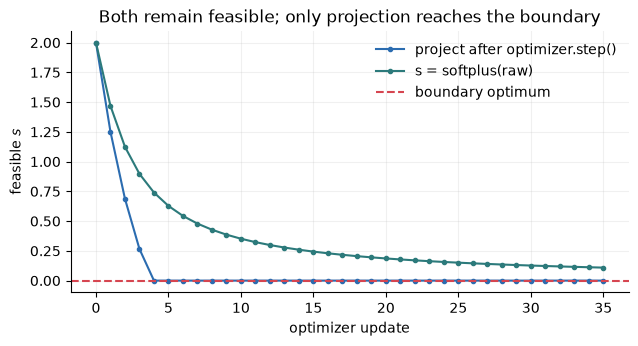

projected final s=0.000000 | softplus final s=0.109119


In [12]:
eta, steps = .25, 35

# Closed-set repair: update s directly, then clamp outside autograd.
projected_s = torch.nn.Parameter(torch.tensor(2.0))
projected_opt = torch.optim.SGD([projected_s], lr=eta)
projected = [projected_s.item()]

# Open-set repair: update a raw value and construct s = softplus(raw).
raw_s = torch.nn.Parameter(torch.log(torch.expm1(torch.tensor(2.0))))
raw_opt = torch.optim.SGD([raw_s], lr=eta)
reparameterized = [F.softplus(raw_s).item()]

for _ in range(steps):
    projected_opt.zero_grad(set_to_none=True)
    (.5 * (projected_s + 1).square()).backward()
    projected_opt.step()
    with torch.no_grad():
        projected_s.clamp_(min=0)       # projection follows optimizer.step()
    projected.append(projected_s.item())

    raw_opt.zero_grad(set_to_none=True)
    feasible_s = F.softplus(raw_s)
    (.5 * (feasible_s + 1).square()).backward()
    raw_opt.step()
    reparameterized.append(F.softplus(raw_s).item())

plt.plot(projected, 'o-', ms=3, color=BLUE, label='project after optimizer.step()')
plt.plot(reparameterized, 'o-', ms=3, color=TEAL, label='s = softplus(raw)')
plt.axhline(0, color=RED, ls='--', label='boundary optimum')
plt.xlabel('optimizer update'); plt.ylabel('feasible $s$')
plt.title('Both remain feasible; only projection reaches the boundary')
plt.legend(frameon=False); plt.show()
print(f'projected final s={projected[-1]:.6f} | softplus final s={reparameterized[-1]:.6f}')
assert projected[-1] == 0.0 and reparameterized[-1] > 0.0

### Reusable projection pattern—and one warning

Clamp **after** the optimizer step and outside autograd:

```python
loss.backward()
optimizer.step()
with torch.no_grad():
    model.nonnegative_parameter.clamp_(min=0)
```

With momentum or Adam, clamping changes the parameter but does **not** erase the optimizer's stored momentum/EMA state; that state was computed before projection and may keep pushing outward. Monitor this interaction or use a constraint-aware update when the boundary is active frequently.

Use reparameterization for a smooth strict-interior constraint; use projection when the exact boundary is a valid, meaningful solution.

## Takeaways

1. RMSProp tracks `square_avg`; Adam tracks `exp_avg` and `exp_avg_sq`. We checked the complete parameter and state histories against our recurrences.
2. Learning-rate numbers are convention-dependent; small final losses are printed in scientific notation rather than rounded to zero.
3. The inverse-time schedule $\eta_t=\eta_0/(1+dt)$ is implemented by `LambdaLR` and advanced once per optimizer update in both the experiment and code.
4. An unconstrained step can make a Gaussian scale negative. Optimizing a raw value and rebuilding `softplus(raw)` inside the forward pass guarantees strict positivity.
5. Projection can reach an exact boundary: clamp after `optimizer.step()` under `no_grad`. Momentum/Adam state is not automatically projected or reset.